<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - **Main Notes 2026/01** (Francisco Förster Burón):  
>   - https://github.com/fforster/AS4501/tree/main
> - Valetino Gonzales:
>   - https://github.com/cefuente/astroinformatica
> - Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> Paula Caceres, Javiera Toro, Melissa FuenteAlba, ..

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astroML.datasets

rc_params = {
   'mathtext.fontset': 'cm',     # Set default mathtext font
   'font.family': 'STIXGeneral', # Set default font family
   'xtick.direction': 'in',      # Set default xtickdirecion
   'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
   'ytick.direction': 'in',      # Set default ytickdirecion
   'ytick.minor.visible': True,  # visibility of minor ticks on y-axis
   'grid.linestyle': ':',        # Set grid linestyle
   'grid.alpha': 0.6,            # Set grid transparency
   
}
plt.rcParams.update(rc_params)

CSPEED = 3e5 # km/s

We use the `astroML.datasets.generate_mu_z` module to create a simulated dataset of redshift vs. luminosity distance. The library outputs the distance modulus ($\mu$), so we first need to convert it into luminosity distance ($d_L$, in Megaparsecs) using the following formula:

$$\mu = 5 \log_{10}(d_L) + 25$$

Solving for $d_L$, we get:
$$d_L = 10^{\frac{\mu - 25}{5}}$$

For this regression exercise, we are assuming a simple linear relationship:
$$d_L = \theta_1 z + \theta_0$$

where $d_L$ is the luminosity distance, $z$ is the redshift, and $\theta_1$ and $\theta_0$ are the slope and intercept, respectively. Physically, at low redshifts ($z \ll 1$), this linear relationship represents Hubble's Law ($cz = H_0 d_L$). Therefore, the slope $\theta_1$ is directly related to the Hubble Constant ($H_0$) by the relation $\theta_1 = c / H_0$, where $c$ is the speed of light.In vector form, this can be expressed as the product of the parameter row vector $\boldsymbol{\theta}^T$ and the feature column vector $\mathbf{x}$:

$$d_L = \boldsymbol{\theta}^T \mathbf{x} = \begin{pmatrix} \theta_1 & \theta_0 \end{pmatrix} \begin{pmatrix} z \\ 1 \end{pmatrix}$$

The expected value in this notebook is $H_0 = 71 \text{ km/s/Mpc}$.

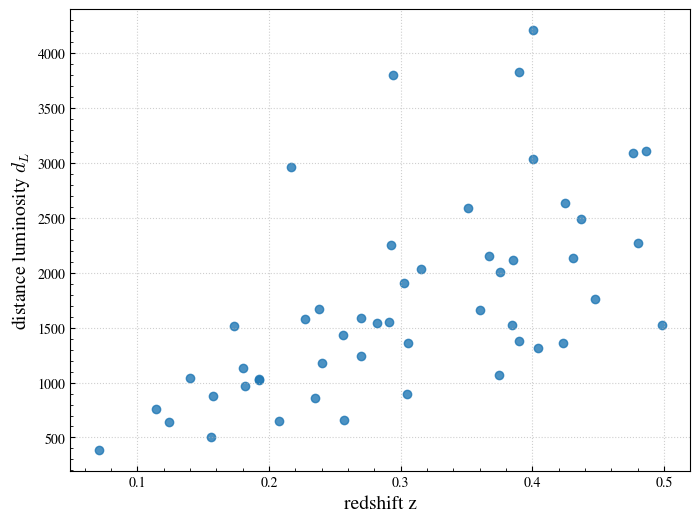

In [116]:
# Genererating data
z_sample, mu_sample, _  = astroML.datasets.generate_mu_z(100, random_state=42)
mask = z_sample < 0.5
z_sample, mu_sample  = z_sample[mask], mu_sample[mask]
mu2dl     = lambda mu: 10**((mu - 25) / 5)
dL_sample = mu2dl(mu_sample) #/ 1000 # Convert to Gpc


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, dL_sample, alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$', fontsize=14)
plt.grid()
plt.show()

In [117]:
X = z_sample.reshape(-1, 1)
y = dL_sample

print('Redshift z:', z_sample,'\n', 'Shape:', z_sample.shape)
print('Matrix X:', X,'\n', 'Shape:', X.shape)
print('Distance modulus mu:', y,'\n', 'Shape:', y.shape)

Redshift z: [0.436657   0.27005693 0.2700366  0.17312131 0.11413956 0.3154359
 0.29131424 0.29258659 0.38462246 0.47995544 0.37498936 0.25587674
 0.37566788 0.43057269 0.49859179 0.30553284 0.15773364 0.28212075
 0.1816404  0.38489719 0.21699618 0.48626001 0.24026268 0.13960262
 0.35081231 0.39014304 0.29375198 0.20764192 0.30261964 0.1560119
 0.40020283 0.44721399 0.36021212 0.42344165 0.36734864 0.2571252
 0.19260711 0.30477788 0.07053003 0.19203936 0.42471132 0.23455457
 0.40431526 0.17985184 0.38960456 0.40009425 0.23801444 0.47658646
 0.12386752 0.22700015] 
 Shape: (50,)
Matrix X: [[0.436657  ]
 [0.27005693]
 [0.2700366 ]
 [0.17312131]
 [0.11413956]
 [0.3154359 ]
 [0.29131424]
 [0.29258659]
 [0.38462246]
 [0.47995544]
 [0.37498936]
 [0.25587674]
 [0.37566788]
 [0.43057269]
 [0.49859179]
 [0.30553284]
 [0.15773364]
 [0.28212075]
 [0.1816404 ]
 [0.38489719]
 [0.21699618]
 [0.48626001]
 [0.24026268]
 [0.13960262]
 [0.35081231]
 [0.39014304]
 [0.29375198]
 [0.20764192]
 [0.30261964]


Assuming that the true relationship between our variables is linear, but our measurements (e.g., flux from a telescope) contain a random error $\epsilon_i$:

$$y_i = \mathbf{X}_i \theta + \epsilon_i$$

By the Central Limit Theorem, we can assume that this instrumental noise is normally distributed with a mean of zero and a constant variance $\sigma^2$, such that $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$. Therefore, the probability of observing a specific value $y_i$, given our features $\mathbf{X}_i$ and parameterized by our model $\theta$, follows a Gaussian distribution:

$$P(y_i | \mathbf{X}_i; \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2} \right)$$

We want to find the model parameters $\theta$ that maximize the probability of obtaining the data we actually observed. Assuming that our $n$ observations (for instance, a sample of 100 supernovae) are independent, the total joint probability is the product of their individual probabilities. This is known as the Likelihood Function, $L(\theta)$:

$$L(\theta) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2} \right)$$

Since the natural logarithm is a strictly increasing function, the value of $\theta$ that maximizes $L(\theta)$ will also maximize its logarithm, $\ln L(\theta)$. Using the log-likelihood is mathematically convenient because it converts the product into a sum and "brings down" the exponent of the Gaussian:
$$
\begin{aligned}
\ln L(\theta) &= \sum_{i=1}^{n} \ln \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2} \right) \right] \\
\ln L(\theta) &= n \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \sum_{i=1}^{n} \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2}
\end{aligned}
$$
To maximize the log-likelihood with respect to $\theta$, we can ignore the first term because it is a constant (it does not depend on $\theta$). Furthermore, the factor $\frac{1}{2\sigma^2}$ in the second term is also a positive constant multiplier. Thus, maximizing the overall probability is mathematically equivalent to minimizing the subtracted squared term:

$$\text{Minimize:} \sum_{i=1}^{n} (y_i - \mathbf{X}_i\theta)^2$$

This demonstrates that minimizing the Residual Sum of Squares (RSS) in Ordinary Least Squares (OLS) is exactly equivalent to performing Maximum Likelihood Estimation under the assumption of Gaussian noise.

To find the optimal parameters for our linear model, we minimize the **Residual Sum of Squares (RSS)**. The cost function $J(\theta)$ is defined as the squared norm of the residual vector:
$$J(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|^2 = (\mathbf{y} - \mathbf{X}\theta)^T(\mathbf{y} - \mathbf{X}\theta)$$

Using the properties of the transpose, $(A - B)^T = A^T - B^T$, we expand the expression:

$$\begin{aligned}
J(\theta) &= (\mathbf{y}^T - \theta^T\mathbf{X}^T)(\mathbf{y} - \mathbf{X}\theta) \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\theta - \theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - 2\theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta
\end{aligned}$$

Since $\mathbf{y}^T\mathbf{X}\theta$ is a scalar, it is equal to its own transpose $(\theta^T\mathbf{X}^T\mathbf{y})$. To find the minimum, we differentiate $J(\theta)$ with respect to the parameter vector $\theta$ and set the gradient to zero:
$$\frac{\partial J(\theta)}{\partial \theta} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\theta$$

Solving for $\theta$ to find the optimal value $\hat{\theta}$:
$$\begin{aligned}
-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\hat{\theta} &= 0 \\
\mathbf{X}^T\mathbf{X}\hat{\theta} &= \mathbf{X}^T\mathbf{y} \\
\hat{\theta} &= \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T\mathbf{y}
\end{aligned}$$

In linear regression, we seek the weights (intercept $\theta_0$ and slope $\theta_1$) that minimize the sum of squared residuals. The analytical solution is the Normal Equation:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{y}$$



In [118]:
# Create the design matrix by adding a column of ones for the intercept term
X_mat = np.column_stack((np.ones(X.shape[0]), X))
print('Matrix X_mat:', X_mat,'\n', 'Shape:', X_mat.shape, end='\n\n')

# Apply the normal equation to compute the coefficients
# theta = (X^T @ X)^(-1) @ X^T @ y
theta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y
print('Intercept (theta[0]):', theta[0])
print('Slope (theta[1]):', theta[1])

Matrix X_mat: [[1.         0.436657  ]
 [1.         0.27005693]
 [1.         0.2700366 ]
 [1.         0.17312131]
 [1.         0.11413956]
 [1.         0.3154359 ]
 [1.         0.29131424]
 [1.         0.29258659]
 [1.         0.38462246]
 [1.         0.47995544]
 [1.         0.37498936]
 [1.         0.25587674]
 [1.         0.37566788]
 [1.         0.43057269]
 [1.         0.49859179]
 [1.         0.30553284]
 [1.         0.15773364]
 [1.         0.28212075]
 [1.         0.1816404 ]
 [1.         0.38489719]
 [1.         0.21699618]
 [1.         0.48626001]
 [1.         0.24026268]
 [1.         0.13960262]
 [1.         0.35081231]
 [1.         0.39014304]
 [1.         0.29375198]
 [1.         0.20764192]
 [1.         0.30261964]
 [1.         0.1560119 ]
 [1.         0.40020283]
 [1.         0.44721399]
 [1.         0.36021212]
 [1.         0.42344165]
 [1.         0.36734864]
 [1.         0.2571252 ]
 [1.         0.19260711]
 [1.         0.30477788]
 [1.         0.07053003]
 [1.       

To measure the accuracy of our model, we calculate the **Mean Squared Error** (MSE). This metric tells us, on average, how far our predictions are from the true astronomical observations
$$\text{MSE}=\frac{1}{n}\sum_{i=1}^{n} \left(y_i - \hat y_i\right)^2$$

where $n$ is the total number of data point, $y_i$ is the real (observed) value, and $\hat y_i$ is the predicted value by the model.

(*Note:* Be careful when interpreting this number! The MSE is highly sensitive to the scale of your variables because it outputs the squared units of your dependent variable (in this case, $\text{Mpc}^2$). A large MSE does not necessarily mean the model is terrible; it is often just a consequence of working with large cosmological distances.)

In [119]:
dL_pred = X_mat @ theta
mse = np.mean((dL_pred - y) ** 2)
print('Mean Squared Error:', mse)

Mean Squared Error: 502594.138183999


In [120]:
z_fit  = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100)
X_fit  = np.column_stack((np.ones(z_fit.shape[0]), z_fit.reshape(-1, 1)))
dL_fit = X_fit @ theta 

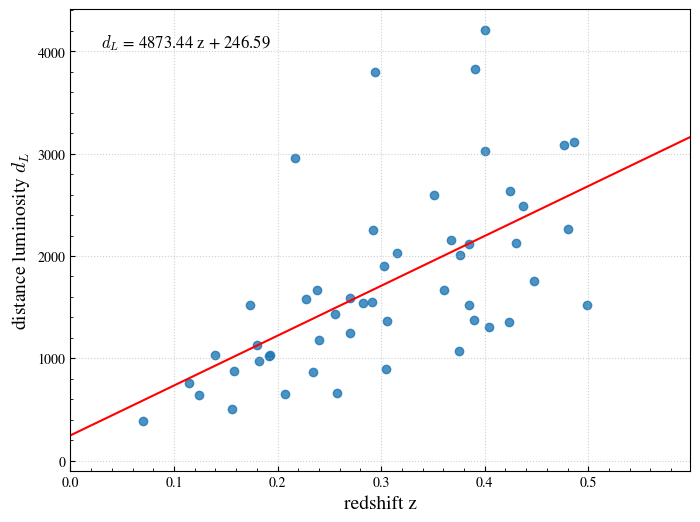

In [121]:
sign = '+' if theta[1] >= 0 else '-'
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, dL_sample, alpha=0.8)
ax.plot(z_fit, dL_fit, color='red', label='Linear Fit')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$', fontsize=14)
ax.text(0.05, 0.95, fr'$d_L$ = {theta[1]:.2f} z {sign} {np.abs(theta[0]):.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
#ax.legend()
plt.grid()
plt.show()

Libraries such as `scikit-learn` and `SciPy` already have these methods implemented. In this lecture, we will prioritize `scikit-learn` because it is the standard for Machine Learning and will be used frequently throughout the rest of this course. However, we also encourage you to explore the `SciPy` documentation.

In [122]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X, y)

intercept_sklearn = model.intercept_
slope_sklearn     = model.coef_[0]

print('Intercept (sklearn):', intercept_sklearn)
print('Slope (sklearn):', slope_sklearn)

dL_pred_sklearn = model.predict(X)
mse_sklearn     = mean_squared_error(y, dL_pred_sklearn)
print('MSE (sklearn):', mse_sklearn)

Intercept (sklearn): 246.59018149150643
Slope (sklearn): 4873.444262949442
MSE (sklearn): 502594.13818399893


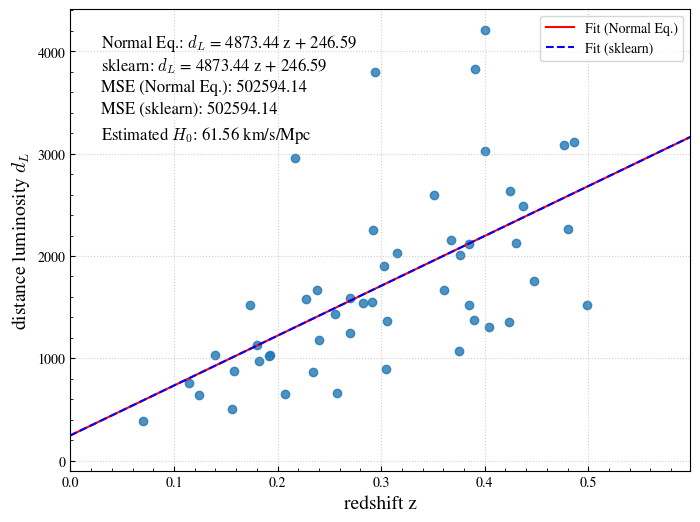

In [123]:
theta_sklearn  = np.array([intercept_sklearn, slope_sklearn])
dL_fit_sklearn = X_fit @ theta_sklearn 

sign = '+' if intercept_sklearn >= 0 else '-'
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, dL_sample, alpha=0.8)
ax.plot(z_fit, dL_fit, color='red', label='Fit (Normal Eq.)')
ax.plot(z_fit, dL_fit_sklearn, color='blue', linestyle='--', label='Fit (sklearn)')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$', fontsize=14)
ax.text(0.05, 0.95, fr'Normal Eq.: $d_L$ = {theta[1]:.2f} z {sign} {np.abs(theta[0]):.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.90, fr'sklearn: $d_L$ = {slope_sklearn:.2f} z {sign} {np.abs(intercept_sklearn):.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.85, f'MSE (Normal Eq.): {mse:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.80, f'MSE (sklearn): {mse_sklearn:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.75, fr'Estimated $H_0$: {CSPEED/slope_sklearn:.2f} km/s/Mpc', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
ax.legend()
plt.grid()
plt.show()

**General Case:** TThe OLS derivation assumes that all errors are equal and independent of each other. However, in real astronomical data, this is rarely true. Each observation typically has a different uncertainty, requiring us to work with the Covariance Matrix $\mathbf{C}$:

$$\mathbf{C} = \begin{bmatrix} 
\sigma_1^2 & \sigma_{12} & \dots & \sigma_{1n} \\
\sigma_{21} & \sigma_2^2 & \dots & \sigma_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{n1} & \sigma_{n2} & \dots & \sigma_n^2 
\end{bmatrix}$$

In this case, the cost function $J(\theta)$ (often referred to as $\chi^2$ in astronomy) is weighted by the inverse of the covariance matrix:

$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta)$$

The general solution for the optimal parameters, known as Weighted Least Squares, is:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{C}^{-1}\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{C}^{-1} \mathbf{y}$$

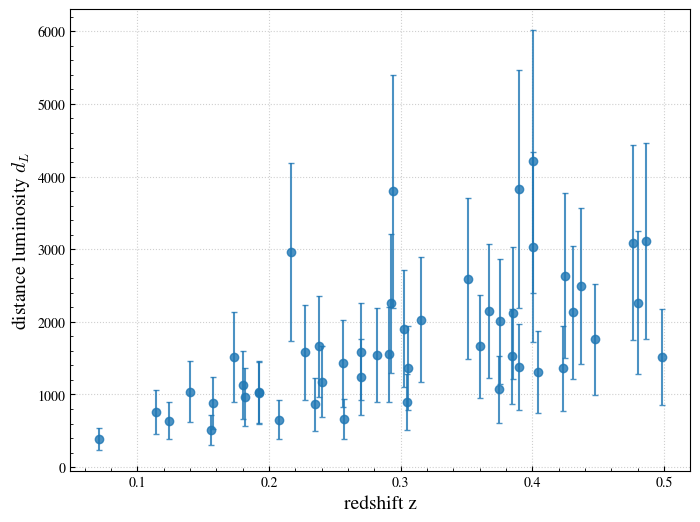

In [124]:
z_sample, mu_sample, dmu_sample  = astroML.datasets.generate_mu_z(100, random_state=42)
mask = z_sample < 0.5
z_sample, mu_sample, dmu_sample  = z_sample[mask], mu_sample[mask], dmu_sample[mask]

mu2dl      = lambda mu: 10**((mu - 25) / 5)
dL_sample  = mu2dl(mu_sample) #/ 1000 # Convert to Gpc
ddL_sample = dL_sample * (np.log(10) / 5) * dmu_sample

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', capsize=2, alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$', fontsize=14)
plt.grid()
plt.show()

In [125]:
# 
X_mat = np.column_stack((np.ones(z_sample.shape), z_sample))

# We are assuming that the errors in dL sample are independent and normally distributed
# with variances given by ddL_sample**2.
# Inverse of the covariance matrix (weights)
Cinv = np.diag(1 / ddL_sample**2)

# Compute the weighted least squares solution
theta_weighted = np.linalg.inv(X_mat.T @ Cinv @ X_mat) @ X_mat.T @ Cinv @ dL_sample

print('Weighted Intercept:', theta_weighted[0])
print('Weighted Slope:', theta_weighted[1]) 

# Compute the chi-squared statistic
dL_pred = X_mat @ theta_weighted
chi_squared = np.sum(((dL_sample - dL_pred) / ddL_sample) ** 2)
print('Chi-squared:', chi_squared)

Weighted Intercept: 137.97900060621163
Weighted Slope: 3923.0124416732674
Chi-squared: 32.46006399192509


In [126]:
X_sklearn_weighted = z_sample.reshape(-1, 1)

# Weights (Inverse of Covariance Matrix)
weights = 1 / ddL_sample**2

model_weighted = LinearRegression()
model_weighted.fit(X_sklearn_weighted, dL_sample, sample_weight=weights)

print('Weighted Intercept:', model_weighted.intercept_)
print('Weighted Slope:', model_weighted.coef_[0])

dL_pred_weighted     = model_weighted.predict(X_sklearn_weighted)
chi_squared_weighted = np.sum(((dL_sample - dL_pred_weighted) / ddL_sample) ** 2)
print('Chi-squared (sklearn):', chi_squared_weighted)


Weighted Intercept: 137.97900060621112
Weighted Slope: 3923.0124416732697
Chi-squared (sklearn): 32.46006399192509


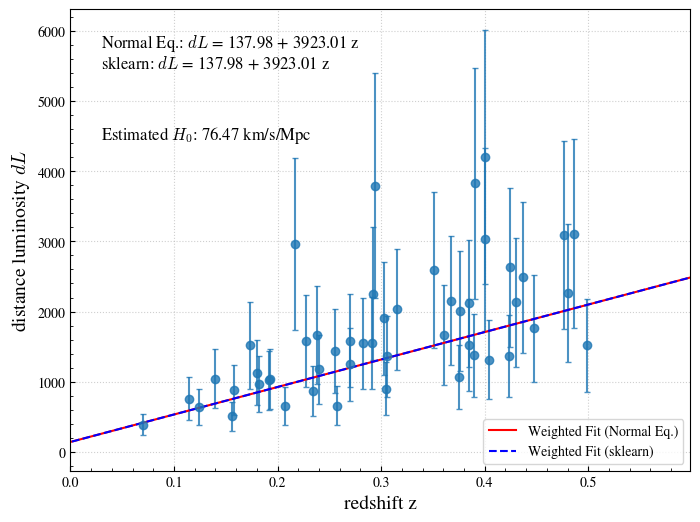

In [127]:
z_fit = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100).reshape(-1, 1)
X_fit_weighted = np.column_stack((np.ones(z_fit.shape[0]), z_fit))
dL_fit_weighted = X_fit_weighted @ theta_weighted
dL_fit_weighted_sklearn = model_weighted.predict(z_fit)

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', capsize=2, alpha=0.8)
ax.plot(z_fit, dL_fit_weighted, color='red', label='Weighted Fit (Normal Eq.)')
ax.plot(z_fit, dL_fit_weighted_sklearn, color='blue', linestyle='--', label='Weighted Fit (sklearn)')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $dL$', fontsize=14)
ax.text(0.05, 0.95, fr'Normal Eq.: $dL$ = {theta_weighted[0]:.2f} + {theta_weighted[1]:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.90, fr'sklearn: $dL$ = {model_weighted.intercept_:.2f} + {model_weighted.coef_[0]:.2f} z', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.75, fr'Estimated $H_0$: {CSPEED/model_weighted.coef_[0]:.2f} km/s/Mpc', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
ax.legend()
plt.grid()
plt.show()


Preguntas para ustedes,

¿Qué pasa si usamos todo el set de datos para entrenar y nada para testear?

¿Por qué OLS tiene problemas con datos complejos?

# Regularization: Ridge and Lasso

Ordinary Least Squares (OLS) can be prone to overfitting when there is a lot of noise in the data or when we have many correlated features. What can we do in that case? We introduce Regularization, which adds a penalty to the cost function to restrict the model's complexity.

There are two main approaches:

1. **Ridge Regression ($L_2$ Regularization):** Ridge penalizes high coefficients but keeps all features in the model. The cost function $J(\theta)$ adds an $L_2$ penalty term ($\alpha \theta^T \theta$) to the standard Residual Sum of Squares:

$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta) + \alpha\theta^T\theta$$

Following the same derivative steps derived previously, and knowing that the derivative of the penalty term is $\frac{\partial}{\partial \theta}(\alpha \theta^T \theta) = 2\alpha\theta$, we get:
$$\frac{\partial J(\theta)}{\partial \theta} = -2\mathbf{X}^T\mathbf{C}^{-1}\mathbf{y} + 2\mathbf{X}^T\mathbf{C}^{-1}\mathbf{X}\theta + 2\alpha\theta $$

Setting the gradient equal to $0$:
$$\mathbf{X}^T\mathbf{X}\hat{\theta} + \alpha\hat{\theta} = \mathbf{X}^T\mathbf{C}^{-1}\mathbf{y}$$

To factor out $\hat{\theta}$, we multiply the scalar $\alpha$ by the Identity Matrix $\mathbf{I}$ (since $\mathbf{I}\hat{\theta} = \hat{\theta}$):
$$
\begin{aligned}
\mathbf{X}^T\mathbf{X}\hat{\theta} + \alpha \mathbf{I} \hat{\theta} &= \mathbf{X}^T\mathbf{C}^{-1}\mathbf{y} \\
(\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})\hat{\theta} &= \mathbf{X}^T\mathbf{C}^{-1}\mathbf{y}
\end{aligned}
$$
Finally, solving for $\hat{\theta}$, we find the analytical solution for Ridge:

$$\hat{\theta}_{ridge} = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1}\mathbf{X}^T\mathbf{C}^{-1}\mathbf{y}$$

(Note: In practice, the intercept $\theta_0$ is not penalized, so the first element of the identity matrix $\mathbf{I}$ is set to $0$).


2. **Lasso Regression ($L_1$ Regularization):** Lasso applies an absolute value penalty. Its main advantage is that it can force some coefficients to become exactly zero, effectively performing automatic feature selection and simplifying the model.The cost function is:
$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T\mathbf{C}^{-1}(\mathbf{y} - \mathbf{X}\theta) + \alpha \sum_{j=1}^{p} |\theta_j|$$

Why is it not possible to obtain an analytical solution for $\hat{\theta}_{lasso}$?

How do we solve it? (Coordinate Descent)
Since we lack a simple formula, we must use numerical optimization algorithms like Coordinate Descent.

Regardless of the method chosen (Ridge or Lasso), $\alpha$ serves as a tuning hyperparameter. It controls the trade-off between fitting the training data perfectly and keeping the model weights small to prevent overfitting.

**The Role of $\alpha$ (The Penalty Term)**

- If $\alpha = 0$: The penalty disappears completely. The cost function becomes identical to the standard OLS (Ordinary Least Squares).
- If $\alpha \to \infty$: The penalty dominates the cost function. The model will force all coefficients ($\theta$) to approach zero, resulting in a flat horizontal line (a model that predicts the mean, suffering from underfitting).

How do we choose $\alpha$?

Since $\alpha$ is a hyperparameter, it is not learned by the Normal Equation or Coordinate Descent. We, as astronomers/data scientists, must find the optimal value through Cross-Validation, testing different values of $\alpha$ to see which one yields the lowest error on unseen data.

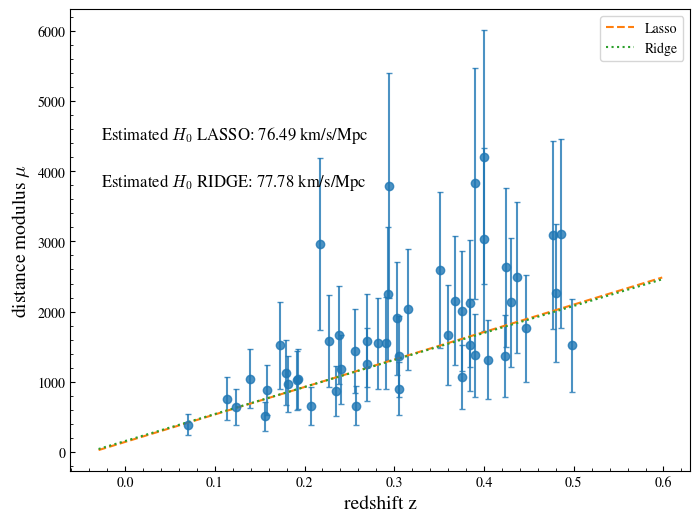

In [138]:
from sklearn.linear_model import Ridge, Lasso

# Fit Lasso and Ridge
alpha = 0.01
#alpha = 1e-9
weights = 1 / ddL_sample**2
weights = weights / np.mean(weights)

lasso = Lasso(alpha=alpha)
ridge = Ridge(alpha=alpha)
lasso.fit(X_sklearn_weighted, dL_sample, sample_weight=weights)
ridge.fit(X_sklearn_weighted, dL_sample, sample_weight=weights)

z_fit = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100).reshape(-1, 1)
X_fit_weighted = np.column_stack((np.ones(z_fit.shape[0]), z_fit))
dL_fit_weighted_lasso = lasso.predict(z_fit)
dL_fit_weighted_ridge = ridge.predict(z_fit)

# Predecimos
#y_pred_lasso = lasso.predict(X_sklearn_weighted)
#y_pred_ridge = ridge.predict(X_sklearn_weighted)

# Comparamos modelos
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', capsize=2, alpha=0.8)
#ax.plot(X, y_pred, color="red", label="OLS")
ax.plot(z_fit, dL_fit_weighted_lasso,color='C1',linestyle="dashed", label="Lasso")
ax.plot(z_fit, dL_fit_weighted_ridge,color='C2',linestyle="dotted", label="Ridge")
ax.text(0.05, 0.75, fr'Estimated $H_0$ LASSO: {CSPEED/lasso.coef_[0]:.2f} km/s/Mpc', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.65, fr'Estimated $H_0$ RIDGE: {CSPEED/ridge.coef_[0]:.2f} km/s/Mpc', transform=ax.transAxes, fontsize=12, verticalalignment='top')

ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance modulus $\mu$', fontsize=14)
ax.legend()


plt.show()

Manejo de outliers: Regresión de Huber
Si tenemos outliers, OLS no hace el fit correctamente, pues los errores son muy grandes.

Así, la regresión de Huber combina OLS con una perdida absoluta, de esta forma puede manejar los outlier y ser más robusta.

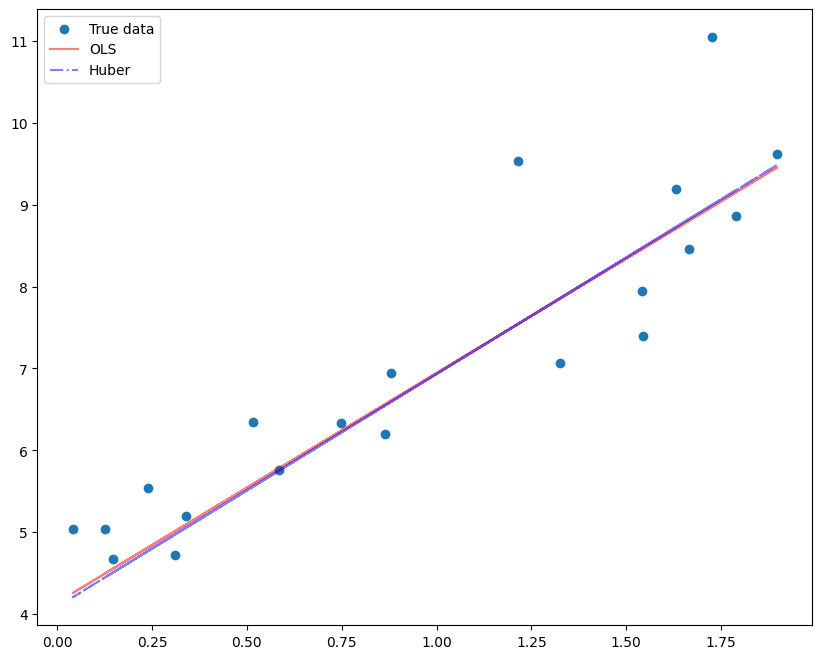

In [ ]:
from sklearn.linear_model import HuberRegressor

# Agregamos outliers a la muestra
y_outliers = y.copy()
y_outliers[95:] += 10  # Agregamos errores grandes

# Fit Huber Regression
huber = HuberRegressor()
huber.fit(X_train, y_train.ravel())

# Predecimos
y_pred_huber = huber.predict(X_test)

# Comparamos modelos
fig = plt.figure(figsize=(10,8))
plt.scatter(X_test, y_test, label="True data")
plt.plot(X_test, y_pred, color="red", label="OLS", alpha=0.5)
plt.plot(X_test, y_pred_huber, color="blue", linestyle="dashdot",
         label="Huber",alpha=0.5)
plt.legend()
plt.show()

| Methodology | Description |
|------------|-------------|
| OLS        | Use this as a baseline for well-behaved, linear datasets where you expect Gaussian noise and no significant outliers. |
| Ridge      | Useful when features are highly correlated (e.g., multiple galaxy color indices) |
| Lasso      | Ideal for automatic feature selection (e.g., identifying the most relevant spectral lines). |
| Huber      | Robust against measurement errors and extreme values (e.g., observations of variable stars). |

In [ ]:
# Fetching real galaxy data
data = astroML.datasets.fetch_nasa_atlas()

In [ ]:
mask = (data['VDISP'] > 0) & (data['Z'] > 0) & (data['PETROTH50'] > 0)
data = data[mask]
data = pd.DataFrame({
    # Convertimos el radio angular a radio físico aproximado usando el redshift (Z)
    'log_Re': np.log10(data['PETROTH50'] * data['Z']),
    # Logaritmo de la dispersión de velocidades
    'log_sigma': np.log10(data['VDISP']),
    # Magnitud absoluta en banda r (índice 4 del vector ABSMAG)
    'Mr': data['ABSMAG'][:,4]
})
data = data.replace([np.inf, -np.inf], np.nan).dropna()
data.reset_index(drop=True, inplace=True)
data = data[:100]  # Limitamos a 1000 galaxias para acelerar el proceso
data.shape, data.columns, data.head()

((100, 3),
 Index(['log_Re', 'log_sigma', 'Mr'], dtype='str'),
      log_Re  log_sigma         Mr
 0 -1.133606   2.120125 -19.667040
 1 -0.918776   1.621217 -18.400158
 2 -1.346841   1.199230 -15.508064
 3 -0.763240   2.018366 -20.400579
 4 -1.076029   1.744785 -16.589527)

$$\log R_e = \theta_0 + \theta_1 \log \sigma + \theta_2 \mu$$

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Defined the features (X) and target variable (y)
X = data[['log_sigma','Mr']]
y = data['log_Re']

model = LinearRegression()
model.fit(X.values, y)

y_pred = model.predict(X)
mse    = mean_squared_error(y, y_pred)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean Squared Error:', mse)

Coefficients: [-0.20775138 -0.08169744]
Intercept: -2.1061428
Mean Squared Error: 0.043693531304597855


/home/jurados/AS4501_Astroinformatic/Astroinformatic/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


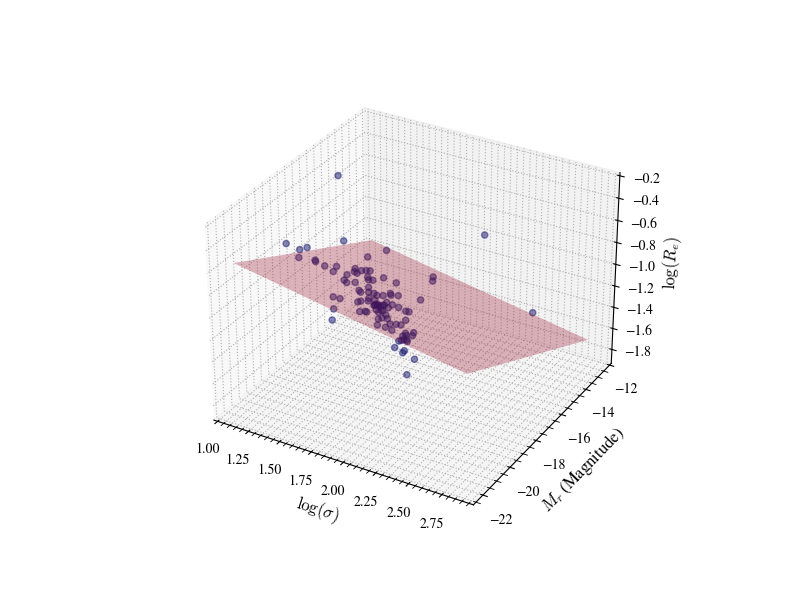

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': '3d'})

ax.scatter(data['log_sigma'], data['Mr'], data['log_Re'], 
           color='midnightblue', alpha=0.5, label='Galaxies')

# 2. Creamos la malla para representar el plano de ajuste
x_range = np.linspace(data['log_sigma'].min(), data['log_sigma'].max(), 20)
y_range = np.linspace(data['Mr'].min(), data['Mr'].max(), 20)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

# Predicción sobre la malla (necesitamos aplanarla para el modelo)
mesh_points = np.c_[x_mesh.ravel(), y_mesh.ravel()]
z_mesh = model.predict(mesh_points).reshape(x_mesh.shape)

# 3. Graficamos el plano (superficie)
ax.plot_surface(x_mesh, y_mesh, z_mesh, color='crimson', alpha=0.3)

# Etiquetas y Estilo
ax.set_xlabel(r'$\log(\sigma)$', fontsize=12)
ax.set_ylabel(r'$M_r$ (Magnitude)', fontsize=12)
ax.set_zlabel(r'$\log(R_e)$', fontsize=12)

plt.show()